# 勇者傳說 — Overworld Elf Regeneration V1 (T4 GPU)

Regenerate **char_elf** overworld sprite with improved chibi proportions.

**Problem**: V3 `char_elf` has non-chibi proportions (too tall/thin, Link-like)
that don't match the style of other characters (hero, NPCs, guard).

**Fix**: Stronger chibi keywords (`cute chibi super deformed, big head small body`),
more specific outfit colors, 5 candidates to pick best match.

**Output**: `overworld_characters/char_elf.png` (64×96 RGBA)

## 0. Cleanup

In [1]:
import os, shutil
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

# Delete old elf progress
for f in OUTPUT_BASE.glob('_progress_owc_elf_*.json'):
    f.unlink()
    print(f'  Deleted: {f.name}')

print('Ready.')

Mounted at /content/drive
Ready.


## 1. Setup

In [2]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
import numpy as np
from scipy import ndimage
from pathlib import Path
from PIL import Image

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')
for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
assert torch.cuda.is_available(), 'ERROR: GPU required!'
DEVICE = 'cuda'
DTYPE = torch.float16
print(f'GPU: {torch.cuda.get_device_name(0)}')

def free_vram():
    gc.collect()
    torch.cuda.empty_cache()

def largest_connected_component(rgba_img):
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30
    struct = ndimage.generate_binary_structure(2, 2)
    dilated = ndimage.binary_dilation(mask, struct, iterations=3)
    labeled, n_features = ndimage.label(dilated, structure=struct)
    if n_features <= 1: return rgba_img
    sizes = ndimage.sum(mask, labeled, range(1, n_features + 1))
    largest_label = np.argmax(sizes) + 1
    keep_mask = (labeled == largest_label) & mask
    result = arr.copy()
    result[~keep_mask] = [0, 0, 0, 0]
    return Image.fromarray(result)

def quality_score(rgba_img, tw=64, th=96):
    arr = np.array(rgba_img)
    mask = arr[:, :, 3] > 30
    fill = np.sum(mask) / (tw * th)
    rows = np.any(mask, axis=1)
    if not np.any(rows): return 0.0, 0.0, 0.0
    first = np.argmax(rows)
    last = len(rows) - np.argmax(rows[::-1]) - 1
    height = (last - first + 1) / rgba_img.height
    return fill * height, fill, height

print('Setup complete')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Load Pipeline

In [3]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

LORA_WEIGHT = 0.8

cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print('Downloading SDXL...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        'stabilityai/stable-diffusion-xl-base-1.0',
        torch_dtype=DTYPE, use_safetensors=True, variant='fp16')
    if ON_COLAB:
        pipe.save_pretrained(str(cached))

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

pipe.load_lora_weights('nerijs/pixel-art-xl')
pipe.fuse_lora(lora_scale=LORA_WEIGHT)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()
print('Pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading from cache: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Pipeline ready!


## 3. Elf Prompt Variants

Multiple prompt variants to find the best chibi elf.
Key changes from V3:
- `cute chibi super deformed` — force chibi proportions
- `big round head, small body` — explicit proportion guidance
- More specific colors: `#44aa44 green cloak`, `dark green leather`
- `wooden bow on back` instead of generic `bow`

In [4]:
NEGATIVE = (
    'blurry, text, watermark, signature, multiple characters, duplicate, group, '
    'sprite sheet, multiple views, realistic photo, complex background, border, frame, grid, '
    'tall proportions, long legs, realistic anatomy, slim body, '
    'side view, profile, three quarter view'
)

# Try multiple prompt variants — pick best across all
PROMPTS = [
    # V1: Strong chibi emphasis + detailed outfit
    'pixel art, single cute chibi super deformed character, big round head small body, '
    'elf forest ranger archer, pointed ears, blonde hair with green headband, '
    'bright green cloak, dark green leather armor, wooden bow on back, quiver of arrows, '
    'standing idle front view, dark background',

    # V2: Simpler, game-sprite focused
    'pixel art game sprite, single chibi character, 2-head-tall proportions, '
    'cute elf archer, pointy ears, short blonde hair, green hood and cloak, '
    'dark green tunic, brown leather belt, wooden short bow, '
    'standing front view, solid dark background',

    # V3: RPG character sheet style
    'retro pixel art RPG character, single cute chibi elf, big head tiny body, '
    'pointed ears, golden blonde hair, green ranger cloak flowing, '
    'forest green leather vest, brown boots, wooden bow and arrow quiver on back, '
    'standing idle front facing, dark background',
]

print(f'{len(PROMPTS)} prompt variants')
for i, p in enumerate(PROMPTS):
    print(f'  V{i+1} ({len(p.split())} words): {p[:80]}...')

3 prompt variants
  V1 (44 words): pixel art, single cute chibi super deformed character, big round head small body...
  V2 (36 words): pixel art game sprite, single chibi character, 2-head-tall proportions, cute elf...
  V3 (41 words): retro pixel art RPG character, single cute chibi elf, big head tiny body, pointe...


## 4. Generate + Post-process

5 candidates per prompt variant = 15 total, pick the single best.

In [5]:
from IPython.display import display

TARGET_W, TARGET_H = 64, 96
GUIDANCE = 9.5
STEPS = 30
CANDIDATES_PER_PROMPT = 5
MIN_FILL = 0.15
MIN_HEIGHT = 0.50

_rembg_session = None
def remove_bg(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except:
        return image.convert('RGBA')

def postprocess(image):
    rgba = remove_bg(image)
    rgba = largest_connected_component(rgba)
    bbox = rgba.getbbox()
    if bbox: rgba = rgba.crop(bbox)
    w, h = rgba.size
    if w == 0 or h == 0:
        return Image.new('RGBA', (TARGET_W, TARGET_H), (0,0,0,0)), 0, 0, 0
    scale = min(TARGET_W / w, TARGET_H / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    rgba = rgba.resize((nw, nh), Image.NEAREST)
    canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0,0,0,0))
    canvas.paste(rgba, ((TARGET_W-nw)//2, TARGET_H-nh), rgba)
    score, fill, height = quality_score(canvas)
    return canvas, score, fill, height

# Reference: load existing hero for style comparison
hero_path = OUTPUT_BASE / 'overworld_characters' / 'char_hero.png'
has_hero_ref = hero_path.exists()
if has_hero_ref:
    hero_img = Image.open(hero_path).convert('RGBA')
    hero_arr = np.array(hero_img)
    hero_mask = hero_arr[:, :, 3] > 30
    hero_avg_rgb = hero_arr[hero_mask][:, :3].astype(float).mean(axis=0) if np.any(hero_mask) else None
    print(f'Hero reference loaded for style comparison')

print(f'\nGenerating {len(PROMPTS)} × {CANDIDATES_PER_PROMPT} = {len(PROMPTS)*CANDIDATES_PER_PROMPT} candidates...\n')

all_candidates = []  # (img, score, fill, height, prompt_idx, seed)

for pi, prompt in enumerate(PROMPTS):
    print(f'\n--- Prompt V{pi+1} ---')
    for c in range(CANDIDATES_PER_PROMPT):
        seed = int(time.time() * 1000) % (2**32) + pi * 1000 + c
        gen = torch.Generator(device=DEVICE).manual_seed(seed)

        result = pipe(
            prompt=prompt, negative_prompt=NEGATIVE,
            width=512, height=768,
            num_inference_steps=STEPS, guidance_scale=GUIDANCE,
            generator=gen,
        )
        img, score, fill, height = postprocess(result.images[0])
        gate = 'PASS' if fill >= MIN_FILL and height >= MIN_HEIGHT else 'FAIL'
        all_candidates.append((img, score, fill, height, pi, seed))
        print(f'  #{len(all_candidates)-1}: score={score:.3f} fill={fill:.2f} h={height:.2f} {gate} seed={seed}')
        free_vram()

print(f'\nTotal candidates: {len(all_candidates)}')
passed = [(i, c) for i, c in enumerate(all_candidates) if c[2] >= MIN_FILL and c[3] >= MIN_HEIGHT]
print(f'Passed quality gate: {len(passed)}')

Hero reference loaded for style comparison

Generating 3 × 5 = 15 candidates...


--- Prompt V1 ---


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

  #0: score=0.474 fill=0.54 h=0.88 PASS seed=3519243103


...

  #12: score=0.558 fill=0.56 h=1.00 PASS seed=3519511904


  0%|          | 0/30 [00:00<?, ?it/s]

  #13: score=0.430 fill=0.44 h=0.97 PASS seed=3519528512


  0%|          | 0/30 [00:00<?, ?it/s]

  #14: score=0.546 fill=0.55 h=1.00 PASS seed=3519545078

Total candidates: 15
Passed quality gate: 15


## 5. Visual Review — All Candidates

Display all candidates in a grid for visual selection.

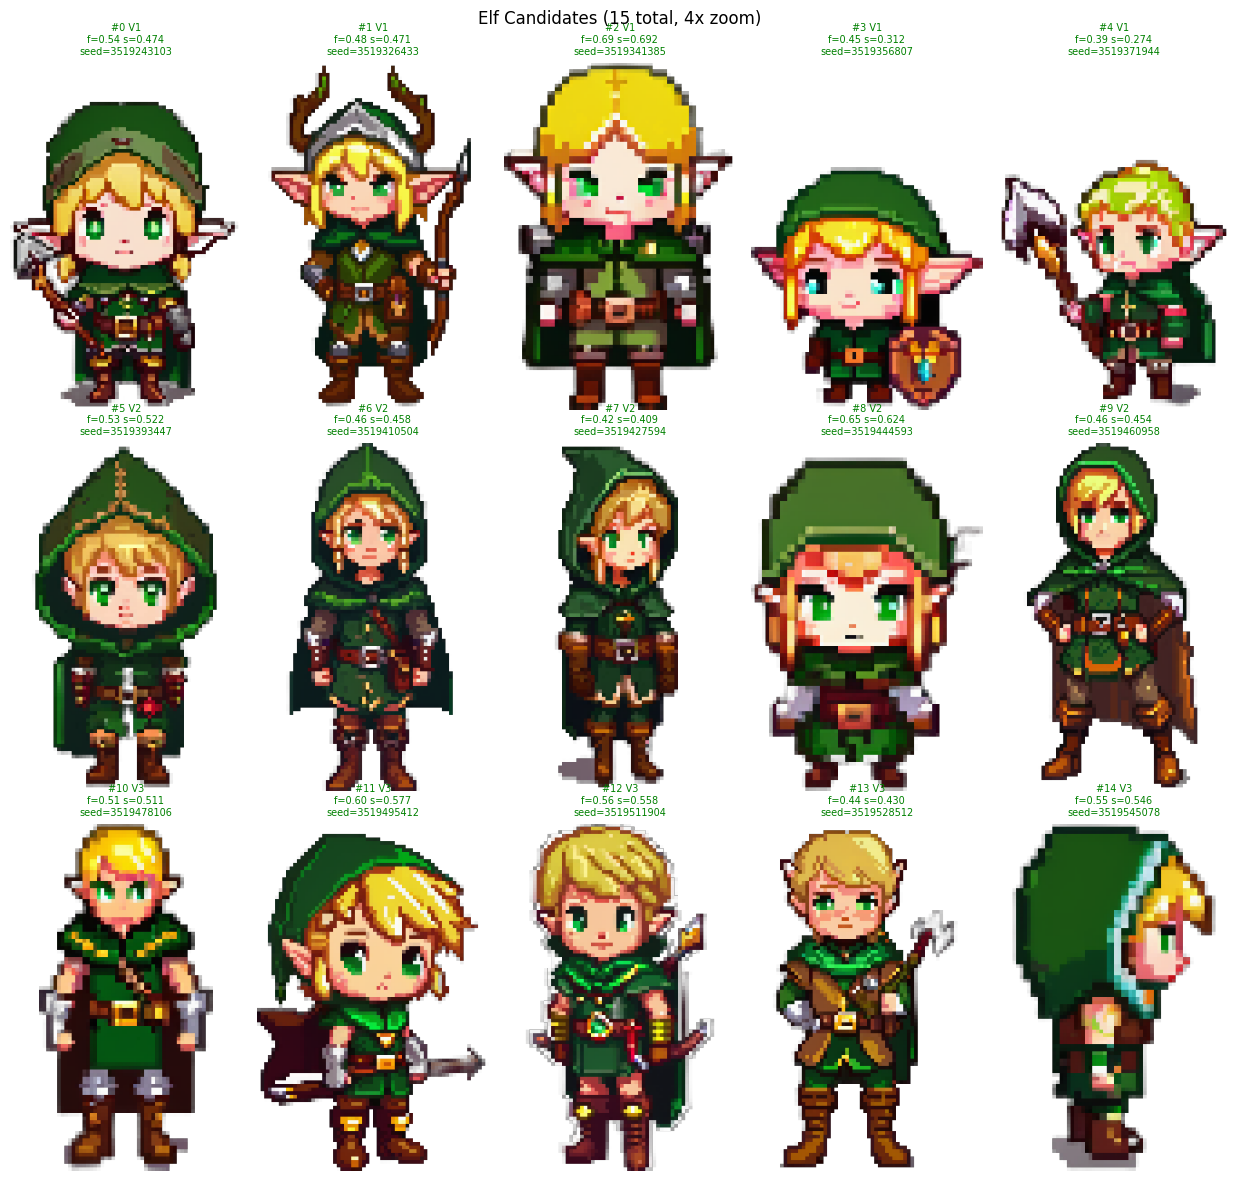


Auto-selected best: #2 (score=0.692, fill=0.69, prompt V1)

Override: Set SELECTED_IDX below if you prefer a different candidate.


In [6]:
import matplotlib.pyplot as plt

n = len(all_candidates)
cols = CANDIDATES_PER_PROMPT
rows = len(PROMPTS)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 4))
if rows == 1: axes = [axes]

for pi in range(rows):
    for c in range(cols):
        idx = pi * cols + c
        ax = axes[pi][c]
        ax.axis('off')
        if idx < n:
            img, score, fill, height, _, seed = all_candidates[idx]
            gate = 'PASS' if fill >= MIN_FILL and height >= MIN_HEIGHT else 'FAIL'
            color = 'green' if gate == 'PASS' else 'red'
            ax.imshow(img.resize((64*4, 96*4), Image.NEAREST))
            ax.set_title(f'#{idx} V{pi+1}\nf={fill:.2f} s={score:.3f}\nseed={seed}',
                        fontsize=7, color=color)

plt.suptitle(f'Elf Candidates ({n} total, 4x zoom)', fontsize=12)
plt.tight_layout()
plt.show()

# Auto-select best by score
valid = [(i, c) for i, c in enumerate(all_candidates) if c[2] >= MIN_FILL and c[3] >= MIN_HEIGHT]
if valid:
    best_idx, best = max(valid, key=lambda x: x[1][1])
    print(f'\nAuto-selected best: #{best_idx} (score={best[1]:.3f}, fill={best[2]:.2f}, prompt V{best[4]+1})')
    print(f'\nOverride: Set SELECTED_IDX below if you prefer a different candidate.')
else:
    print('\nWARNING: No candidates passed quality gate!')

## 6. Select & Save

Change `SELECTED_IDX` if the auto-selected candidate isn't the best visually.

Auto-selected: #2 (score=0.692)
Saved: /content/drive/MyDrive/ai-rpg-game/outputs/overworld_characters/char_elf.png (10 KB)

Final char_elf (6x):


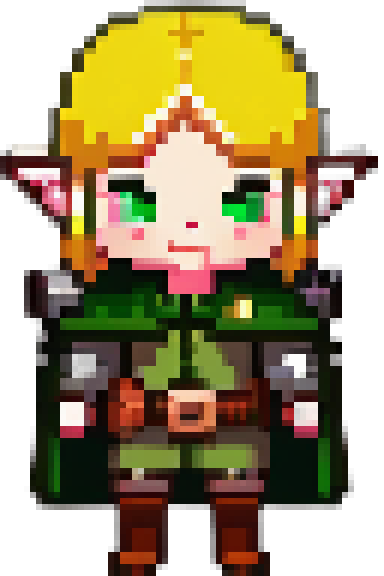


Hero vs New Elf (6x):


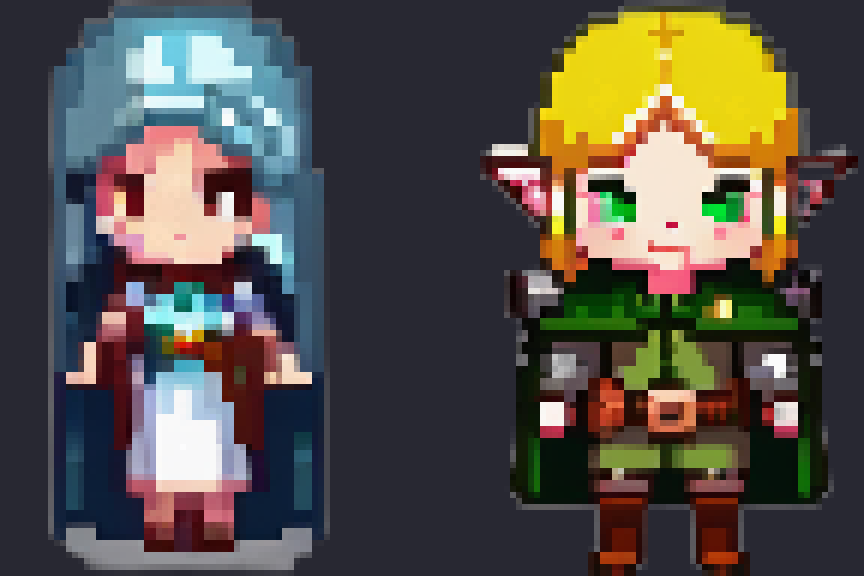

In [7]:
# ──────────────────────────────────────────
# CHANGE THIS if you want a different candidate
SELECTED_IDX = None  # None = auto-select best score
# ──────────────────────────────────────────

if SELECTED_IDX is not None:
    chosen = all_candidates[SELECTED_IDX]
    print(f'Manual selection: #{SELECTED_IDX}')
else:
    valid = [(i, c) for i, c in enumerate(all_candidates) if c[2] >= MIN_FILL and c[3] >= MIN_HEIGHT]
    if valid:
        best_idx, chosen = max(valid, key=lambda x: x[1][1])
        print(f'Auto-selected: #{best_idx} (score={chosen[1]:.3f})')
    else:
        best_idx, chosen = max(enumerate(all_candidates), key=lambda x: x[1][1])
        print(f'Fallback (none passed gate): #{best_idx}')

img = chosen[0]
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'char_elf.png'
img.save(str(out_path), 'PNG')
kb = out_path.stat().st_size / 1024
print(f'Saved: {out_path} ({kb:.0f} KB)')

# Show final at 6x
print(f'\nFinal char_elf (6x):')
display(img.resize((64*6, 96*6), Image.NEAREST))

# Compare with hero if available
if has_hero_ref:
    print('\nHero vs New Elf (6x):')
    compare = Image.new('RGBA', (64*2 + 16, 96), (40, 40, 50, 255))
    compare.paste(hero_img, (0, 0), hero_img)
    compare.paste(img, (64+16, 0), img)
    display(compare.resize((compare.width*6, compare.height*6), Image.NEAREST))

## 7. Export

```bash
bash scripts/import_colab_assets.sh ~/Downloads/owc_elf_v1_output
bash scripts/force_restart_frontend.sh
```

In [8]:
import shutil

# Save progress
progress = OUTPUT_BASE / '_progress_owc_elf_v1.json'
progress.write_text(json.dumps({'selected_idx': SELECTED_IDX or best_idx, 'score': chosen[1], 'seed': chosen[5]}))

zip_path = '/content/owc_elf_v1_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'Zip: {os.path.getsize(zip_path + ".zip") / 1024:.1f} KB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Zip: 8444.5 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>